<a href="https://colab.research.google.com/github/Nagasi77/PCVK-2025/blob/main/Modul6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob


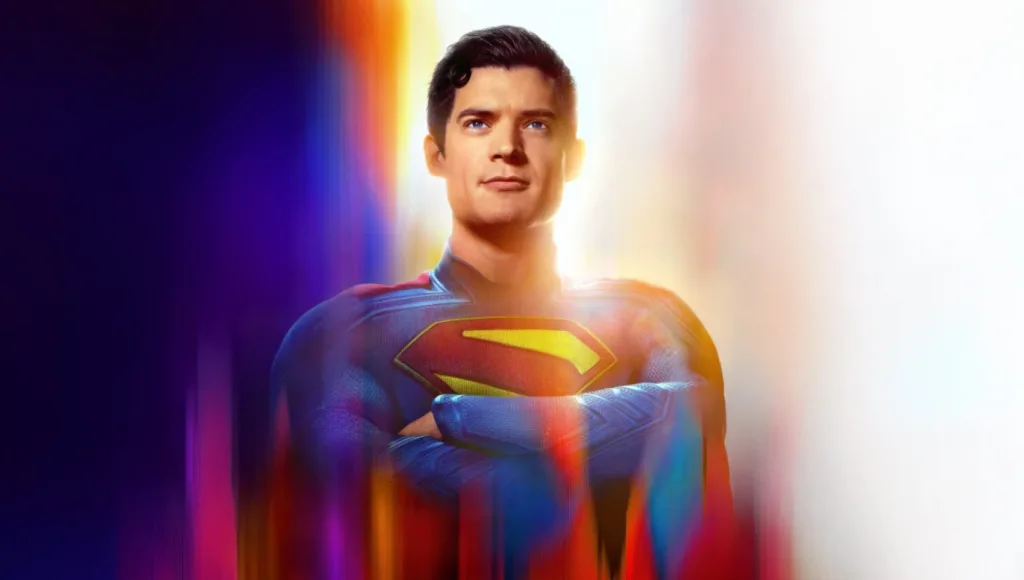

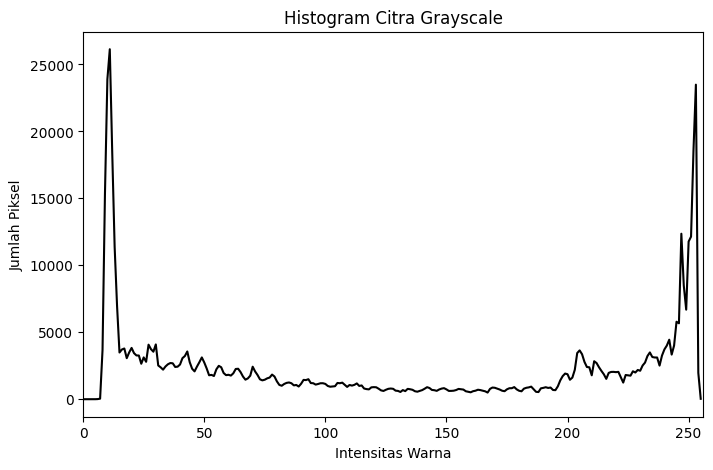

In [10]:
# 1. Input image
img = cv.imread('/content/supes.webp')

# Tampilkan citra asli
cv2_imshow(img)

# 2. Convert ke grayscale (biar 1 channel saja)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 3. Hitung histogram
hist = cv.calcHist([gray], [0], None, [256], [0,256])

# 4. Plot histogram
plt.figure(figsize=(8,5))
plt.title("Histogram Citra Grayscale")
plt.xlabel("Intensitas Warna")
plt.ylabel("Jumlah Piksel")
plt.plot(hist, color='black')
plt.xlim([0,256])
plt.show()

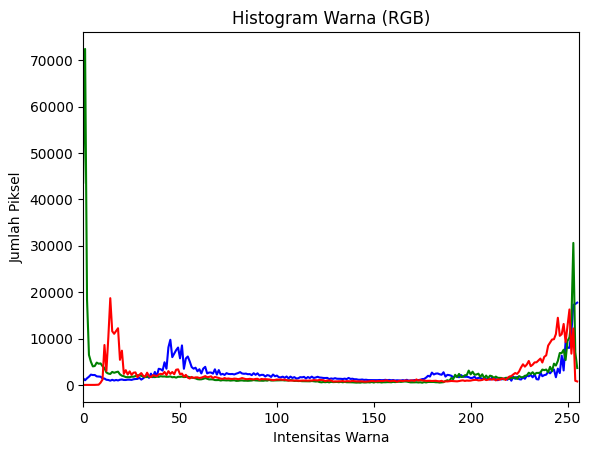

In [11]:
color = ('b','g','r')
for i,col in enumerate(color):
    hist = cv.calcHist([img],[i],None,[256],[0,256])
    plt.plot(hist,color=col)
    plt.xlim([0,256])
plt.title("Histogram Warna (RGB)")
plt.xlabel("Intensitas Warna")
plt.ylabel("Jumlah Piksel")
plt.show()


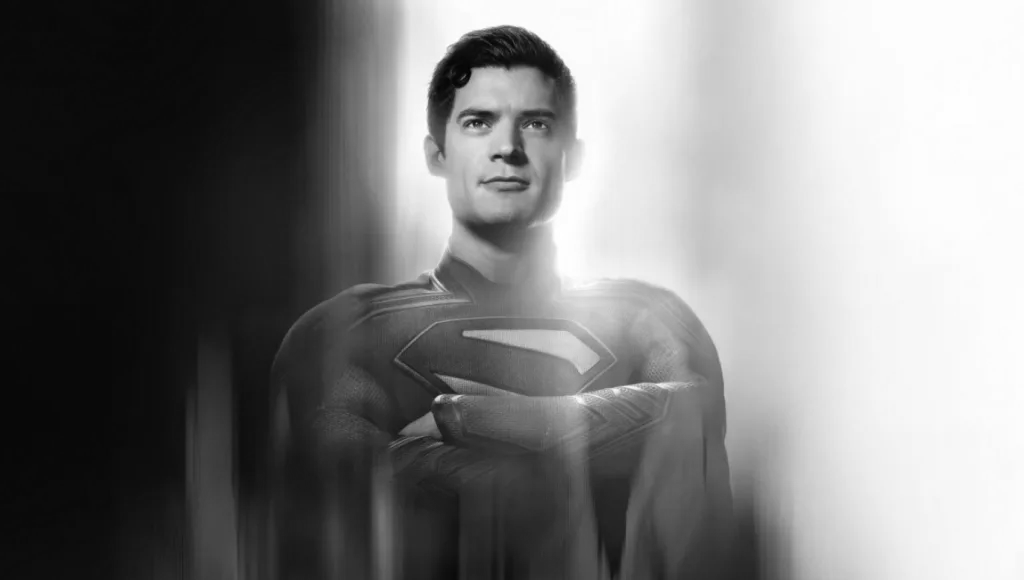

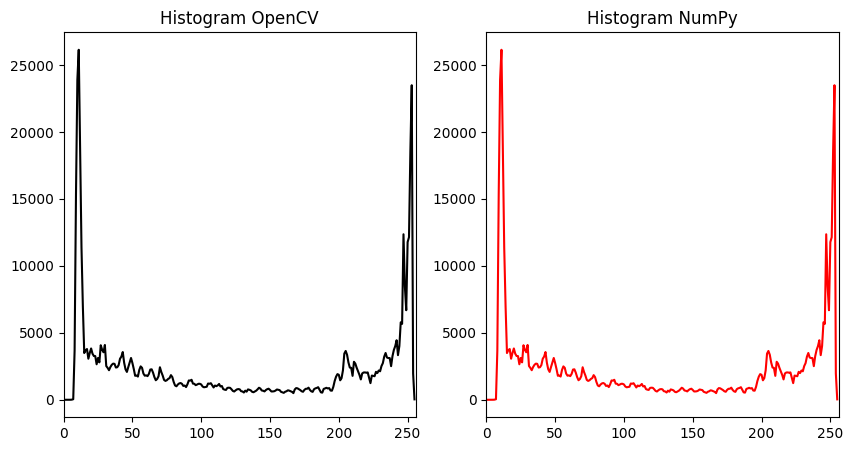

In [12]:


# Load image grayscale
img = cv.imread('/content/supes.webp', cv.IMREAD_GRAYSCALE)

# Tampilkan citra asli
cv2_imshow(img)

# Histogram menggunakan OpenCV
hist_cv = cv.calcHist([img], [0], None, [256], [0,256])

# Histogram menggunakan NumPy
hist_np, bins = np.histogram(img.ravel(), 256, [0,256])

# Plot perbandingan
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Histogram OpenCV")
plt.plot(hist_cv, color='black')
plt.xlim([0,256])

plt.subplot(1,2,2)
plt.title("Histogram NumPy")
plt.plot(hist_np, color='red')
plt.xlim([0,256])
plt.show()


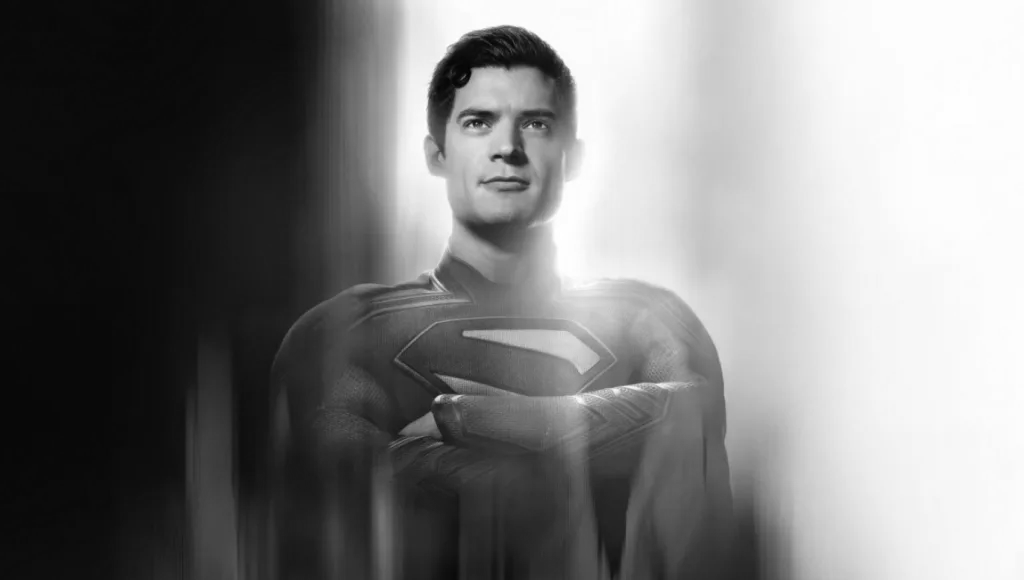

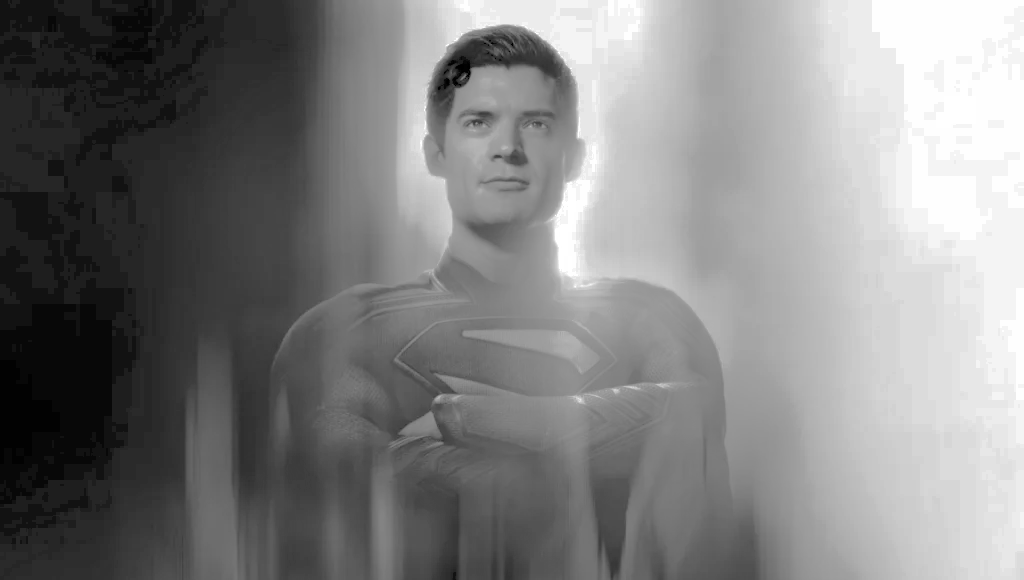

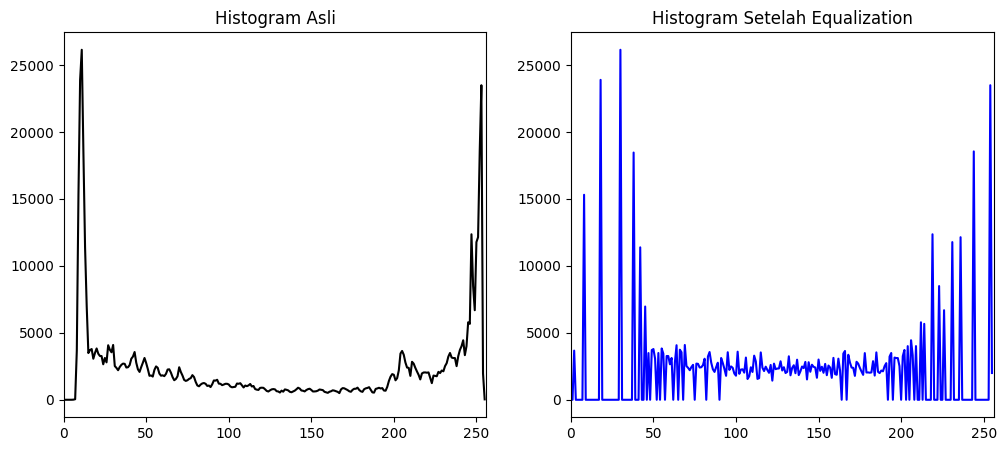

In [13]:
# Histogram Equalization
equalized = cv.equalizeHist(img)

# Tampilkan citra sebelum dan sesudah
cv2_imshow(img)
cv2_imshow(equalized)

# Histogram sebelum & sesudah
hist_orig = cv.calcHist([img],[0],None,[256],[0,256])
hist_eq = cv.calcHist([equalized],[0],None,[256],[0,256])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Histogram Asli")
plt.plot(hist_orig, color='black')
plt.xlim([0,256])

plt.subplot(1,2,2)
plt.title("Histogram Setelah Equalization")
plt.plot(hist_eq, color='blue')
plt.xlim([0,256])
plt.show()


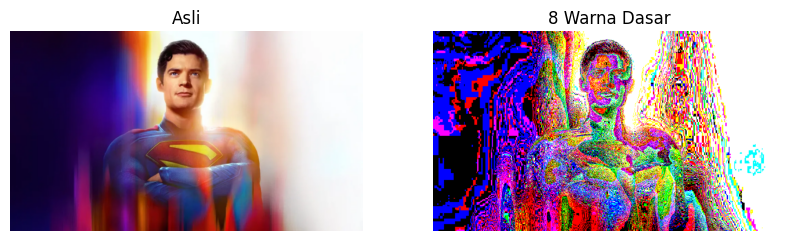

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv2.imread('/content/supes.webp')

# Check if the image was loaded successfully
if img is None:
    print("Error: Image not found or could not be loaded.")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Definisikan 8 warna dasar RGB
    colors = np.array([
        [0, 0, 0],        # hitam
        [255, 255, 255],  # putih
        [255, 0, 0],      # merah
        [0, 255, 0],      # hijau
        [0, 0, 255],      # biru
        [255, 255, 0],    # kuning
        [0, 255, 255],    # cyan
        [255, 0, 255]     # magenta
    ], dtype=np.uint8)

    # Konversi gambar menjadi array 2D
    pixels = img.reshape((-1, 3))

    # Cari warna terdekat untuk setiap pixel
    distances = np.sqrt(((pixels[:, None] - colors[None, :]) ** 2).sum(axis=2))
    nearest_color_index = np.argmin(distances, axis=1)
    quantized_pixels = colors[nearest_color_index]

    # Kembalikan ke bentuk gambar
    quantized_img = quantized_pixels.reshape(img.shape)

    # Tampilkan
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title('Asli')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(quantized_img)
    plt.title('8 Warna Dasar')
    plt.axis('off')
    plt.show()

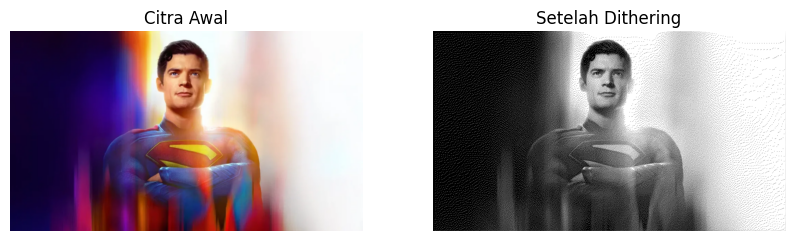

In [15]:
def floyd_steinberg_dithering(img):
    # Ensure the image is grayscale and convert to float
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(float)
    else:
        gray = img.astype(float)

    h, w = gray.shape

    for y in range(h - 1):
        for x in range(1, w - 1):
            old_pixel = gray[y, x]
            new_pixel = 255 if old_pixel > 128 else 0
            gray[y, x] = new_pixel
            error = old_pixel - new_pixel

            # Sebar error ke tetangga
            gray[y, x+1] += error * 7/16
            gray[y+1, x-1] += error * 3/16
            gray[y+1, x] += error * 5/16
            gray[y+1, x+1] += error * 1/16

    return np.clip(gray, 0, 255).astype(np.uint8)

# Use the grayscale image loaded in cell YwaXmJz7QTh9
if 'img' in locals() and img is not None:
    # Terapkan dithering
    dithered = floyd_steinberg_dithering(img)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title('Citra Awal')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(dithered, cmap='gray')
    plt.title('Setelah Dithering')
    plt.axis('off')
    plt.show()
else:
    print("Error: Grayscale image not loaded. Please run the cell loading the grayscale image first.")

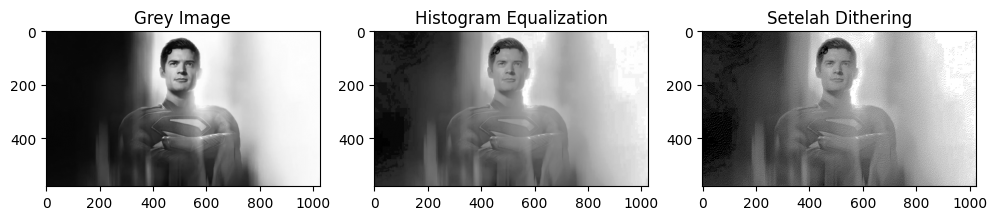

In [17]:
# Baca gambar grayscale
img_lc = cv2.imread('/content/supes.webp', cv2.IMREAD_GRAYSCALE)

# Histogram Equalization
equalized = cv2.equalizeHist(img_lc)

# Dithering setelah equalization
dithered_eq = floyd_steinberg_dithering(cv2.cvtColor(cv2.cvtColor(equalized, cv2.COLOR_GRAY2RGB), cv2.COLOR_RGB2BGR))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_lc, cmap='gray')
plt.title('Grey Image')

plt.subplot(1,3,2)
plt.imshow(equalized, cmap='gray')
plt.title('Histogram Equalization')

plt.subplot(1,3,3)
plt.imshow(dithered_eq, cmap='gray')
plt.title('Setelah Dithering')
plt.show()
